# Data Loading

Loading libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.ensemble import RandomForestClassifier

Loading a file and converting it to a dataframe

Dataset link: https://www.kaggle.com/datasets/sahilislam007/spotify-user-behavior-and-pattern

In [2]:
df = pd.read_csv('../data/spotify_user_behavior_realistic_50000_rows.csv')

# EDA

The first 5 rows of the table

In [3]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


Setting an index and creating new feature "account_age_days"

In [3]:
df.set_index('user_id', inplace=True)
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['account_age_days'] = (datetime.now() - df['signup_date']).dt.days
df['account_age_days'] = df['account_age_days'].astype(float)
df.drop('signup_date', axis=1, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         50000 non-null  object 
 1   age                             50000 non-null  int64  
 2   subscription_type               50000 non-null  object 
 3   subscription_status             50000 non-null  object 
 4   months_inactive                 50000 non-null  int64  
 5   inactive_3_months_flag          50000 non-null  int64  
 6   ad_interaction                  50000 non-null  object 
 7   ad_conversion_to_subscription   50000 non-null  object 
 8   music_suggestion_rating_1_to_5  50000 non-null  int64  
 9   avg_listening_hours_per_week    50000 non-null  float64
 10  favorite_genre                  50000 non-null  object 
 11  most_liked_feature              50000 non-null  object 
 12  desired_future_feature          50000

Histograms

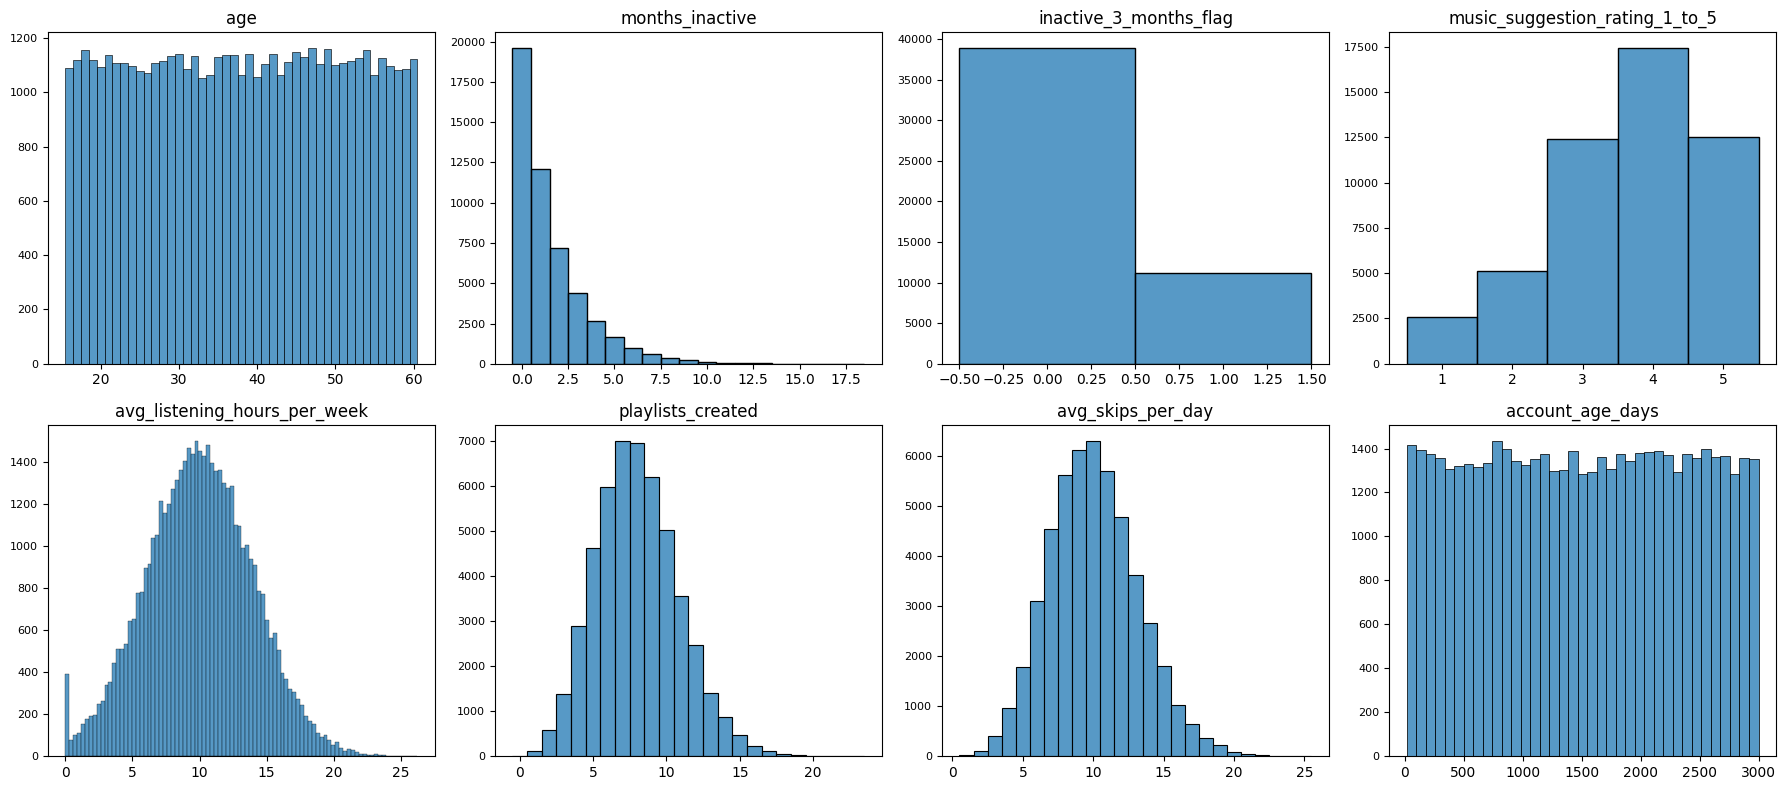

In [5]:
plt.figure(figsize=(18, 8))
inx = 1

for col in df.select_dtypes(exclude='object'):
    plt.subplot(2, 4, inx)
    is_discrete = col not in ['avg_listening_hours_per_week', 'account_age_days']
    sns.histplot(df[col],
                 discrete=is_discrete)
    plt.ylabel('')
    plt.xlabel('')
    plt.yticks(fontsize=8)
    plt.title(col)
    inx += 1

plt.savefig('../visualisations/num_features_histograms.png', format='png')  
plt.tight_layout()
plt.show()

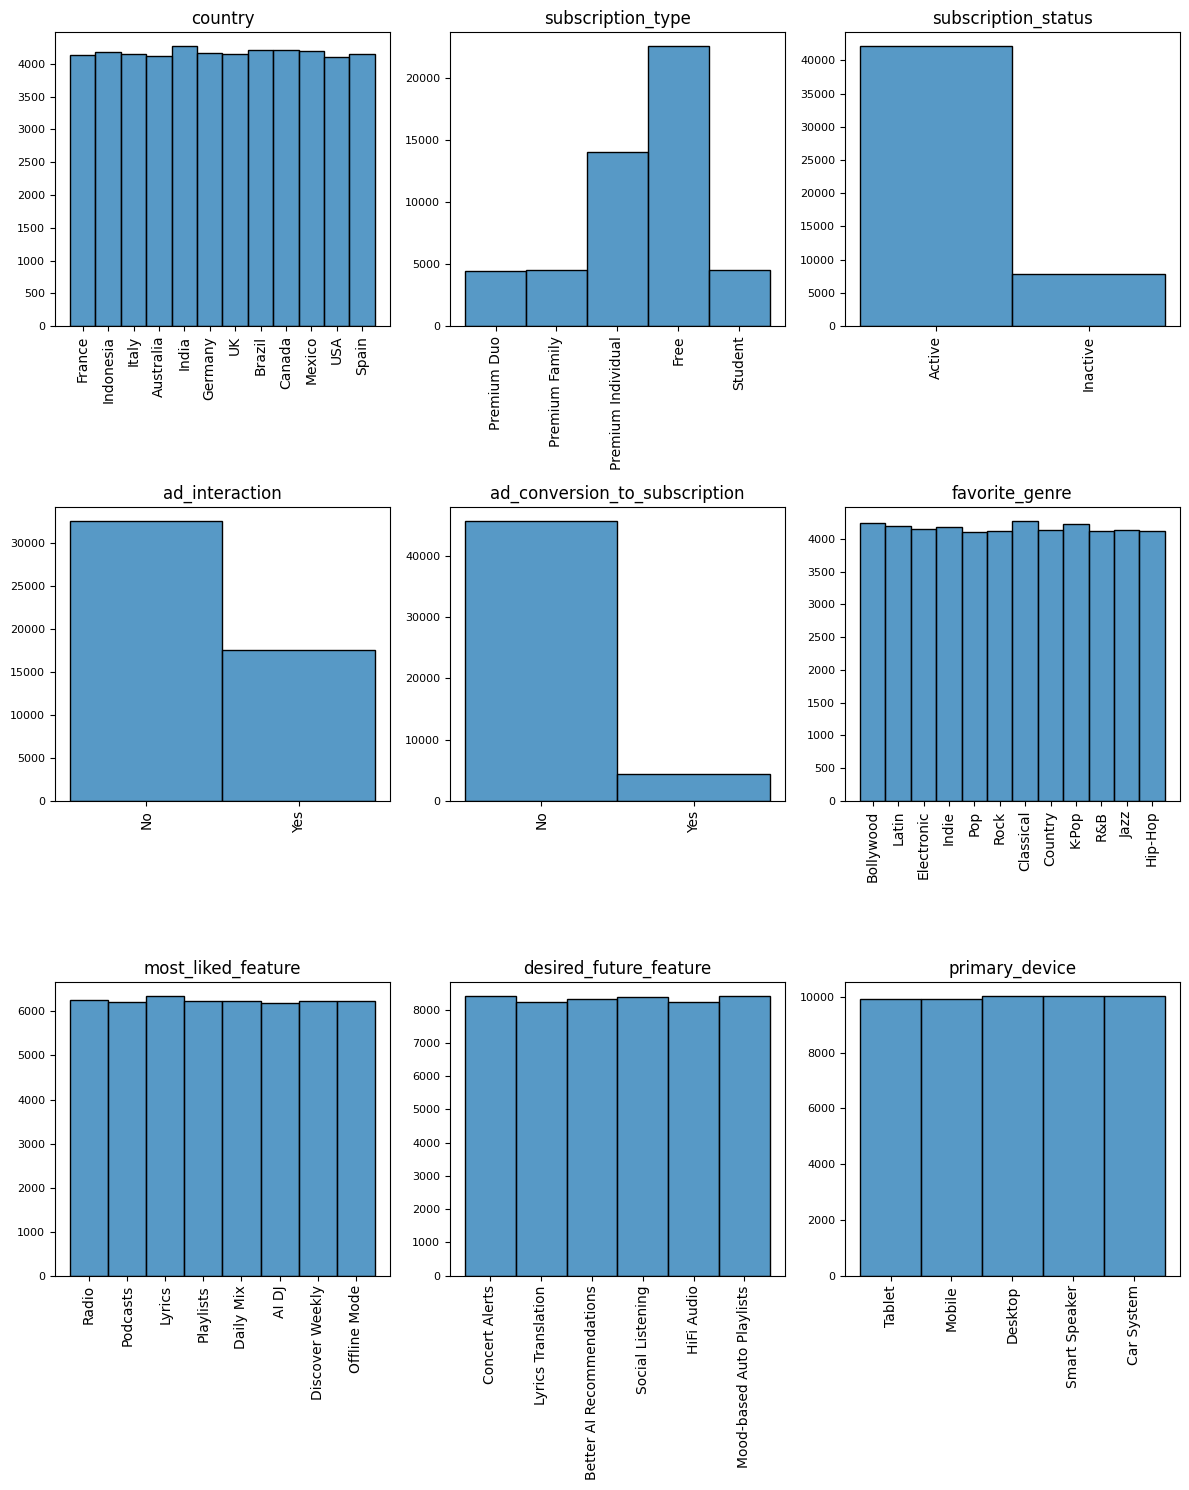

In [8]:
plt.figure(figsize=(12, 15))
inx = 1

for col in df.select_dtypes(include='str'):
    plt.subplot(3, 3, inx)
    sns.histplot(df[col],
                 discrete=True)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.yticks(fontsize=8)
    plt.title(col)
    inx += 1

plt.savefig('../visualisations/cat_features_histograms.png', format='png')  
plt.tight_layout()
plt.show()

# Data Preprocessing

Encoding categorical features

In [4]:
df_encoded = df

for col in df_encoded.select_dtypes(include='str'):
    bin_cols = ['subscription_status', 'ad_interaction', 'ad_conversion_to_subscription']
    drop_first = col in bin_cols
    dummies = pd.get_dummies(df_encoded[col], drop_first=drop_first, prefix=col)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(col, axis=1, inplace=True)

display(df_encoded.head(10))
df_encoded.info()

,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day,account_age_days,country_Australia,country_Brazil,...,desired_future_feature_Concert Alerts,desired_future_feature_HiFi Audio,desired_future_feature_Lyrics Translation,desired_future_feature_Mood-based Auto Playlists,desired_future_feature_Social Listening,primary_device_Car System,primary_device_Desktop,primary_device_Mobile,primary_device_Smart Speaker,primary_device_Tablet
user_id,,,,,,,,,,,,,,,,,,,,,
1,25,0,0,4,10.13,7,8,1673.0,False,False,...,True,False,False,False,False,False,False,False,False,True
2,20,0,0,5,11.63,7,6,1382.0,False,False,...,False,False,True,False,False,False,False,True,False,False
3,53,0,0,3,9.50,6,5,805.0,False,False,...,False,False,False,False,False,False,True,False,False,False
4,48,1,0,4,13.16,11,8,2762.0,False,False,...,False,False,False,False,True,False,False,False,True,False
5,18,0,0,4,12.70,10,11,2120.0,True,False,...,False,False,True,False,False,False,False,False,False,True
6,43,0,0,4,12.51,3,10,2647.0,False,False,...,False,False,False,False,False,True,False,False,False,False
7,21,3,1,4,8.61,13,8,1287.0,False,False,...,False,True,False,False,False,False,False,False,False,True
8,43,1,0,5,8.14,5,16,742.0,False,False,...,False,False,False,False,True,False,False,True,False,False
9,52,2,0,5,7.53,10,21,2757.0,False,False,...,True,False,False,False,False,False,False,True,False,False


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 59 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   age                                               50000 non-null  int64  
 1   months_inactive                                   50000 non-null  int64  
 2   inactive_3_months_flag                            50000 non-null  int64  
 3   music_suggestion_rating_1_to_5                    50000 non-null  int64  
 4   avg_listening_hours_per_week                      50000 non-null  float64
 5   playlists_created                                 50000 non-null  int64  
 6   avg_skips_per_day                                 50000 non-null  int64  
 7   account_age_days                                  50000 non-null  float64
 8   country_Australia                                 50000 non-null  bool   
 9   country_Brazil              

Scaling

In [5]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled

array([[-1.00195771e+00, -7.85333289e-01, -5.34890145e-01, ...,
        -4.98030467e-01, -5.01562016e-01,  2.00853996e+00],
       [-1.38702156e+00, -7.85333289e-01, -5.34890145e-01, ...,
         2.00790929e+00, -5.01562016e-01, -4.97874087e-01],
       [ 1.15439987e+00, -7.85333289e-01, -5.34890145e-01, ...,
        -4.98030467e-01, -5.01562016e-01, -4.97874087e-01],
       ...,
       [-3.85855544e-01, -7.85333289e-01, -5.34890145e-01, ...,
        -4.98030467e-01,  1.99377140e+00, -4.97874087e-01],
       [ 3.84272162e-01, -7.85333289e-01, -5.34890145e-01, ...,
         2.00790929e+00, -5.01562016e-01, -4.97874087e-01],
       [-7.91691282e-04,  7.51502412e-01,  1.86954276e+00, ...,
        -4.98030467e-01, -5.01562016e-01,  2.00853996e+00]],
      shape=(50000, 59))

Reducing dimensionality

In [6]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca

array([[-1.04201697, -0.62794953],
       [-0.92886054, -0.65563183],
       [-1.04044074, -1.71350373],
       ...,
       [-1.02222443, -1.36884143],
       [-0.98051607,  1.41805871],
       [ 2.81961188,  1.43912869]], shape=(50000, 2))

# Clustering

## K-Means

Finding the best k using the elbow method and silhouette score

In [9]:
inertia = []
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(df_pca, kmeans.labels_))

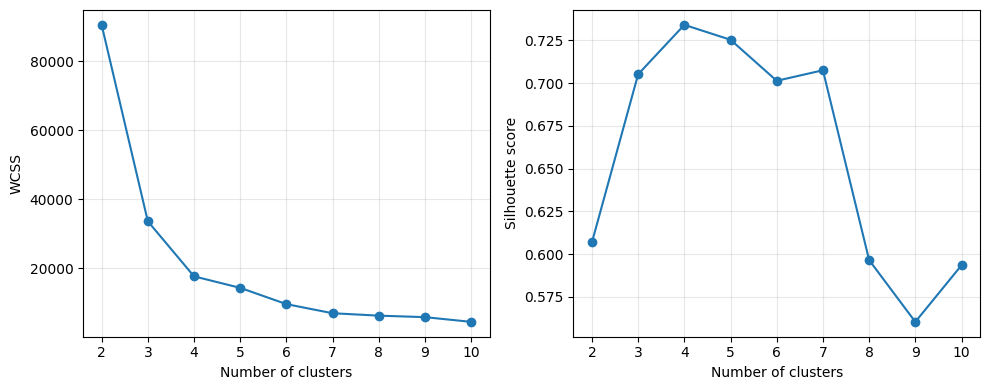

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.grid(alpha=0.3)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette, marker='o')
plt.grid(alpha=0.3)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')

plt.savefig('../visualisations/elbow_method.png', format='png')  
plt.tight_layout()
plt.show()

After k = 4, within-cluster sum of squares stops decreasing sharply, and the silhouette score is at its maximum

In [10]:
kmeans_model = KMeans(n_clusters=4)
kmeans_model.fit_predict(df_pca)

print(f"Silhouette score: {silhouette_score(df_pca, kmeans_model.labels_):.3f}")

Silhouette score: 0.734


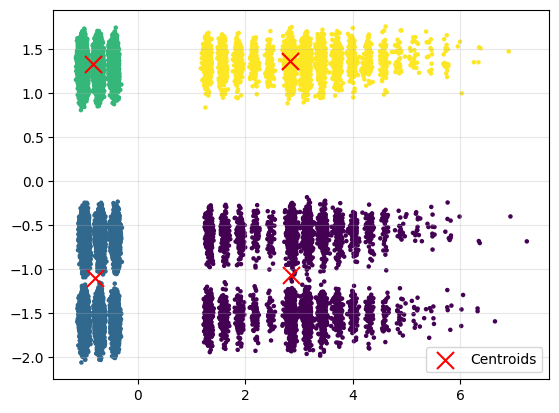

In [12]:
plt.scatter(df_pca[:, 0], 
            df_pca[:, 1],
            c=kmeans_model.labels_,
            s=5)
plt.scatter(kmeans_model.cluster_centers_[:,0], 
            kmeans_model.cluster_centers_[:,1], 
            s = 150, c = 'red', 
            marker = 'x', label = 'Centroids')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../visualisations/kmeans_clusters.png', format='png')  
plt.show()

## Agglomerative Clustering

Verifying the correctness by creating an agglomerative clustering model

In [7]:
ac_model = AgglomerativeClustering(n_clusters=4)
ac_model.fit_predict(df_pca)

print(f'Silhouette score: {silhouette_score(df_pca, ac_model.labels_):.3f}')

Silhouette score: 0.734


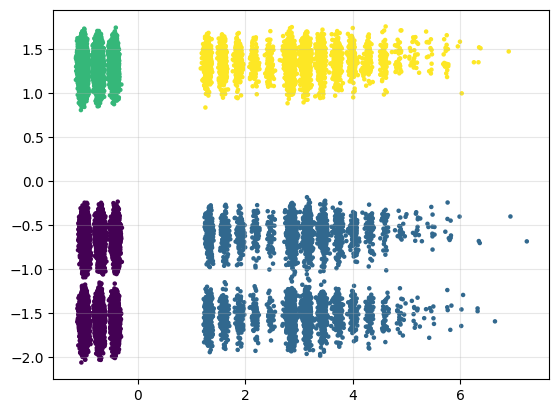

In [8]:
plt.scatter(df_pca[:, 0], 
            df_pca[:, 1],
            c=ac_model.labels_,
            s=5)
plt.grid(alpha=0.3)
plt.savefig('../visualisations/agg_clusters.png', format='png')  
plt.show()

In [11]:
ari = adjusted_rand_score(kmeans_model.labels_, ac_model.labels_)

print(f'Adjusted rand score: {ari:.3f}')

Adjusted rand score: 1.000


Complete match

# Interpretation of clustering results

Adding a column with cluster numbers

In [12]:
df['cluster'] = kmeans_model.labels_
df.head()

,country,age,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,account_age_days,cluster
user_id,,,,,,,,,,,,,,,,,,
1,France,25,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8,1673.0,1
2,Indonesia,20,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6,1382.0,1
3,Italy,53,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5,805.0,1
4,Italy,48,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8,2762.0,1
5,Australia,18,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11,2120.0,2


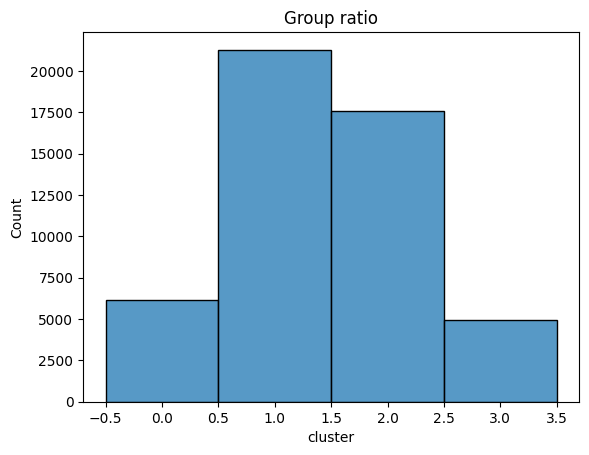

In [13]:
sns.histplot(df['cluster'], discrete=True)
plt.title('Group ratio')
plt.savefig('../visualisations/groups.png', format='png')  
plt.show()

Evaluating the importance of features using random forest classifier

In [14]:
rf = RandomForestClassifier(n_jobs=-1,
                            class_weight='balanced', 
                            random_state=42)
rf.fit(df_encoded, kmeans_model.labels_)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

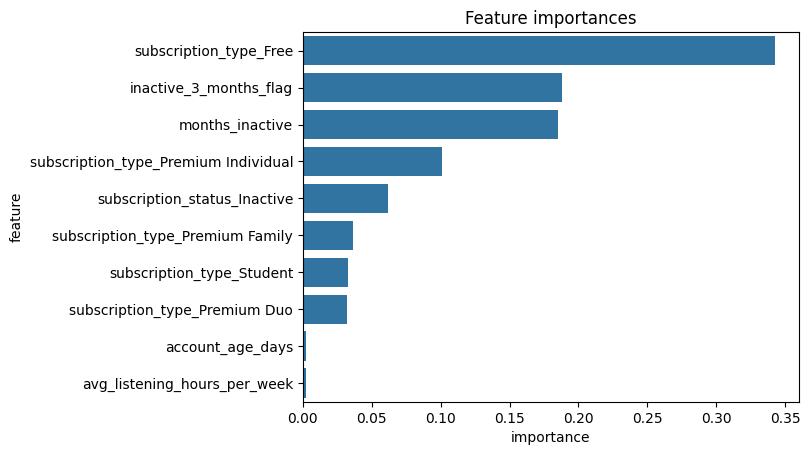

In [15]:
importances = pd.DataFrame({'importance': rf.feature_importances_, 
                            'feature': df_encoded.columns}
                          ).sort_values('importance', ascending=False)

sns.barplot(x=importances['importance'].head(10), 
            y=importances['feature'].head(10))
plt.title('Feature importances')
plt.savefig('../visualisations/agg_clusters.png', format='png')  
plt.show()

The most important features + top country + top genre 

In [16]:
columns = ['Group', 'Number of users', 'Subscription type', 'Average months inactive', 'Subscription status', 'Top country', 'Top genre']
users_portraits = pd.DataFrame(columns=columns)

In [17]:
for c in range(4):
    group = df[df['cluster'] == c]
    row = [c, group.shape[0], 
           group['subscription_type'].value_counts().index[0], 
           group['months_inactive'].mean(),
           group['subscription_status'].value_counts().index[0], 
           group['country'].value_counts().index[0], 
           group['favorite_genre'].value_counts().index[0]]
    users_portraits.loc[c] = row

In [18]:
users_portraits.set_index('Group', inplace=True)

Final users portraits

In [19]:
users_portraits.head()

,Number of users,Subscription type,Average months inactive,Subscription status,Top country,Top genre
Group,,,,,,
0,6180,Premium Individual,4.501456,Inactive,Canada,Latin
1,21295,Premium Individual,0.682742,Active,Germany,K-Pop
2,17582,Free,0.679331,Active,Italy,Electronic
3,4943,Free,4.521343,Inactive,Mexico,Indie


The clustering analysis identified four distinct user segments based on subscription type and activity patterns. 

Groups 1 and 2 represent active users (Premium and Free) with low inactivity periods (~0.68 months), primarily located in Germany and Italy with preferences for K-Pop and Electronic music. 

In contrast, Groups 0 and 3 are inactive users with high inactivity (~4.5 months), based in Canada and Mexico, favoring Latin and Indie genres. A key insight is the "sleeping premium" phenomenon in Group 0 — users who pay but don't actively use the service, representing a potential revenue loss.

Group 3 shows similar inactivity but on free plans, indicating disengaged users who may need re-engagement campaigns. 

These segments provide a foundation for targeted marketing strategies: retaining active premium users, converting active free users, and re-engaging inactive segments through personalized recommendations.